# FinRL GRPO-CVaR — FIXED VERSION

**Fixes applied:**
1. **Signal merge bug** — now properly extracts `llm_sentiment` and `risk` columns
2. **Training instability** — added KL-adaptive early stopping + LR decay
3. **Ablation uses NormalizedEnvWrapper** — no more NaN in ablations
4. **Better reward normalization** — prevents loss spikes

---

In [ ]:
# Cell 1: Install
!pip install -q torch numpy pandas gymnasium scipy
!pip install -q yfinance stockstats datasets huggingface-hub
!pip install -q matplotlib seaborn pyyaml tqdm
print('Done.')

Done.


In [ ]:
# Cell 2: Download data
import os, warnings
warnings.filterwarnings('ignore')
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

from datasets import load_dataset

files = [
    'train_data_2013_2018.csv',
    'train_data_deepseek_sentiment_2013_2018.csv',
    'train_data_deepseek_risk_2013_2018.csv',
    'trade_data_2019_2023.csv',
    'trade_data_deepseek_sentiment_2019_2023.csv',
    'trade_data_deepseek_risk_2019_2023.csv',
]
for f in files:
    print(f'Downloading {f}...')
    ds = load_dataset('benstaf/nasdaq_2013_2023', data_files=f)
    ds['train'].to_csv(f'data/raw/{f}', index=False)
print('Done.')

README.md:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train_data_2013_2018.csv:   0%|          | 0.00/36.5M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Creating CSV from Arrow format:   0%|          | 0/127 [00:00<?, ?ba/s]

...

Repo card metadata block was not found. Setting CardData to empty.


trade_data_deepseek_risk_2019_2023.csv:   0%|          | 0.00/31.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Creating CSV from Arrow format:   0%|          | 0/106 [00:00<?, ?ba/s]

Done.


In [ ]:
# Cell 3: FIX #1 — Proper signal merge
# The bug: sentiment file has column 'llm_sentiment' not 'sentiment'
# Risk file has column 'risk' but merge was failing silently

import pandas as pd
import numpy as np

def prepare_dataset_FIXED(base_path, sentiment_path, risk_path, output_path):
    """Fixed merge that actually finds and uses the LLM signals."""
    base_df = pd.read_csv(base_path)
    sent_df = pd.read_csv(sentiment_path)
    risk_df = pd.read_csv(risk_path)

    # Start with base data
    df = base_df.copy()

    # --- FIX: Find the actual sentiment column ---
    # The sentiment file has columns like 'llm_sentiment' or 'sentiment'
    # Let's check what's actually there
    sent_col = None
    for candidate in ['llm_sentiment', 'sentiment', 'Sentiment', 'LLM_sentiment']:
        if candidate in sent_df.columns:
            sent_col = candidate
            break

    risk_col = None
    for candidate in ['risk', 'Risk', 'llm_risk', 'LLM_risk']:
        if candidate in risk_df.columns:
            risk_col = candidate
            break

    print(f'  Sentiment column found: {sent_col}')
    print(f'  Risk column found: {risk_col}')

    # Also check: does the sentiment file have DIFFERENT columns than base?
    sent_extra = set(sent_df.columns) - set(base_df.columns)
    risk_extra = set(risk_df.columns) - set(base_df.columns)
    print(f'  Extra columns in sentiment file: {sent_extra}')
    print(f'  Extra columns in risk file: {risk_extra}')

    # Merge sentiment
    if sent_col and sent_col in sent_df.columns:
        # Build merge: match on date + tic
        sent_merge = sent_df[['date', 'tic', sent_col]].copy()
        sent_merge = sent_merge.rename(columns={sent_col: 'sentiment'})
        df = df.merge(sent_merge, on=['date', 'tic'], how='left')
        print(f'  Merged sentiment: {df["sentiment"].notna().sum()} non-null values')
    else:
        # If no separate column, check if base already has it
        if 'sentiment' not in df.columns:
            df['sentiment'] = 3.0
            print('  WARNING: No sentiment column found, defaulting to 3.0')

    # Merge risk
    if risk_col and risk_col in risk_df.columns:
        risk_merge = risk_df[['date', 'tic', risk_col]].copy()
        risk_merge = risk_merge.rename(columns={risk_col: 'risk'})
        if 'risk' in df.columns:
            df = df.drop(columns=['risk'])
        df = df.merge(risk_merge, on=['date', 'tic'], how='left')
        print(f'  Merged risk: {df["risk"].notna().sum()} non-null values')
    else:
        if 'risk' not in df.columns:
            df['risk'] = 3.0
            print('  WARNING: No risk column found, defaulting to 3.0')

    # Fill NaN with neutral values
    df['sentiment'] = df['sentiment'].fillna(3.0)
    df['risk'] = df['risk'].fillna(3.0)

    # Clamp to valid range
    df['sentiment'] = df['sentiment'].clip(1, 5)
    df['risk'] = df['risk'].clip(1, 5)

    # Enhanced signal columns
    df['confidence'] = np.where(df['sentiment'] != 3.0, 3.0, 1.0)  # Higher confidence when we have real signal
    df['event_type'] = 'other'
    df['time_horizon'] = 'short'
    df['sentiment_adjusted'] = (df['sentiment'] - 3) * (df['confidence'] / 5.0)
    df['risk_adjusted'] = df['risk'] * (df['confidence'] / 5.0)

    # Clean inf/nan in all numeric columns
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

    df.to_csv(output_path, index=False)

    print(f'\n  Output shape: {df.shape}')
    print(f'  Sentiment: mean={df["sentiment"].mean():.3f}, std={df["sentiment"].std():.3f}')
    print(f'  Risk: mean={df["risk"].mean():.3f}, std={df["risk"].std():.3f}')
    print(f'  Sentiment != 3: {(df["sentiment"] != 3.0).sum()} rows ({(df["sentiment"] != 3.0).mean()*100:.1f}%)')
    print(f'  Risk != 3: {(df["risk"] != 3.0).sum()} rows ({(df["risk"] != 3.0).mean()*100:.1f}%)')

    return df

print('=== Training Data ===')
train_df = prepare_dataset_FIXED(
    'data/raw/train_data_2013_2018.csv',
    'data/raw/train_data_deepseek_sentiment_2013_2018.csv',
    'data/raw/train_data_deepseek_risk_2013_2018.csv',
    'data/processed/train_data_enhanced.csv'
)

print('\n=== Trade Data ===')
trade_df = prepare_dataset_FIXED(
    'data/raw/trade_data_2019_2023.csv',
    'data/raw/trade_data_deepseek_sentiment_2019_2023.csv',
    'data/raw/trade_data_deepseek_risk_2019_2023.csv',
    'data/processed/trade_data_enhanced.csv'
)

=== Training Data ===
  Sentiment column found: llm_sentiment
  Risk column found: llm_risk
  Extra columns in sentiment file: {'llm_sentiment'}
  Extra columns in risk file: {'llm_risk', 'llm_sentiment'}
  Merged sentiment: 47027 non-null values
  Merged risk: 47387 non-null values

  Output shape: (126756, 26)
  Sentiment: mean=3.029, std=0.359
  Risk: mean=2.985, std=0.212
  Sentiment != 3: 12262 rows (9.7%)
  Risk != 3: 5205 rows (4.1%)

=== Trade Data ===
  Sentiment column found: llm_sentiment
  Risk column found: llm_risk
  Extra columns in sentiment file: {'llm_sentiment'}
  Extra columns in risk file: {'llm_risk', 'llm_sentiment'}
  Merged sentiment: 45934 non-null values
  Merged risk: 46142 non-null values

  Output shape: (105588, 26)
  Sentiment: mean=3.075, std=0.467
  Risk: mean=2.967, std=0.312
  Sentiment != 3: 19003 rows (18.0%)
  Risk != 3: 9536 rows (9.0%)


In [ ]:
# Cell 4: Detect columns
train_df = pd.read_csv('data/processed/train_data_enhanced.csv')
stock_dim = train_df['tic'].nunique()

exclude = {'date','tic','close','open','high','low','volume','day',
           'sentiment','risk','confidence','event_type','time_horizon',
           'sentiment_adjusted','risk_adjusted','Unnamed: 0'}
numeric = train_df.select_dtypes(include=[np.number]).columns.tolist()
tech_indicators = [c for c in numeric if c not in exclude]

print(f'Stocks: {stock_dim}')
print(f'Tech indicators ({len(tech_indicators)}): {tech_indicators}')
print(f'Trading days: {train_df["date"].nunique()}')

Stocks: 84
Tech indicators (10): ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma', 'vix', 'turbulence']
Trading days: 1509


In [ ]:
# Cell 5: Environment (same as before)
import gymnasium as gym
from gymnasium import spaces

EVENT_TYPE_MAP = {'earnings':0,'macro':1,'legal':2,'product':3,'other':4}
HORIZON_MAP = {'short':1,'medium':2,'long':3}

class MultiSignalStockTradingEnv(gym.Env):
    def __init__(self, df, stock_dim, hmax=100, initial_amount=1_000_000,
                 transaction_cost_pct=0.001, tech_indicator_list=None,
                 use_signal_state=True, use_action_modulation=True,
                 use_reward_shaping=True, sentiment_weight=0.05,
                 confidence_gate=True, confidence_threshold=3,
                 risk_penalty_weight=0.1, avoidance_bonus_weight=0.05,
                 min_confidence_for_shaping=4):
        super().__init__()
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.tech_indicator_list = tech_indicator_list or []
        self.use_signal_state = use_signal_state
        self.use_action_modulation = use_action_modulation
        self.use_reward_shaping = use_reward_shaping
        self.sentiment_weight = sentiment_weight
        self.confidence_gate = confidence_gate
        self.confidence_threshold = confidence_threshold
        self.risk_penalty_weight = risk_penalty_weight
        self.avoidance_bonus_weight = avoidance_bonus_weight
        self.min_confidence_for_shaping = min_confidence_for_shaping
        self.dates = sorted(df['date'].unique())
        self.date_to_data = {d: df[df['date']==d].sort_values('tic').reset_index(drop=True) for d in self.dates}
        self.n_days = len(self.dates)
        self.signal_features_per_stock = 11 if use_signal_state else 0
        self.state_dim = 1 + stock_dim + stock_dim + len(self.tech_indicator_list)*stock_dim + self.signal_features_per_stock*stock_dim
        self.action_space = spaces.Box(low=-1, high=1, shape=(stock_dim,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_dim,), dtype=np.float32)
        self.day_idx = 0
        self.cash = initial_amount
        self.shares = np.zeros(stock_dim, dtype=np.float32)
        self.asset_memory = [initial_amount]
        self.rewards_memory = []
        self.signal_influence_log = []

    def _get_day_data(self): return self.date_to_data[self.dates[self.day_idx]]
    def _get_prices(self, data): return data['close'].values[:self.stock_dim].astype(np.float32)

    def _get_signal_features(self, data):
        if not self.use_signal_state: return np.array([], dtype=np.float32)
        features = []
        for i in range(min(self.stock_dim, len(data))):
            row = data.iloc[i]
            s,r,c = float(row.get('sentiment',3)), float(row.get('risk',3)), float(row.get('confidence',1))
            h = HORIZON_MAP.get(str(row.get('time_horizon','short')),1)
            e_oh = [0.0]*5; e_oh[EVENT_TYPE_MAP.get(str(row.get('event_type','other')),4)] = 1.0
            features.extend([s,r,c,float(h)] + e_oh + [float(row.get('sentiment_adjusted',s-3)), float(row.get('risk_adjusted',r))])
        expected = self.signal_features_per_stock * self.stock_dim
        while len(features) < expected: features.extend([3,3,1,1,0,0,0,0,1,0,3])
        return np.array(features[:expected], dtype=np.float32)

    def _get_state(self):
        data = self._get_day_data(); prices = self._get_prices(data)
        state = [self.cash] + prices.tolist() + self.shares.tolist()
        for ind in self.tech_indicator_list:
            state.extend(data[ind].values[:self.stock_dim].astype(float).tolist() if ind in data.columns else [0.0]*self.stock_dim)
        return np.concatenate([np.array(state, dtype=np.float32), self._get_signal_features(data)])

    def _modulate_action(self, action):
        if not self.use_action_modulation: return action
        data = self._get_day_data(); mod = action.copy()
        for i in range(min(self.stock_dim, len(data))):
            row = data.iloc[i]; s = float(row.get('sentiment',3)); c = float(row.get('confidence',1))
            cg = 1.0 if (not self.confidence_gate or c >= self.confidence_threshold) else 0.5
            mod[i] = action[i] * (1.0 + self.sentiment_weight * (s-3) * np.sign(action[i]) * cg)
        return mod

    def _compute_reward_shaping(self, actions):
        if not self.use_reward_shaping: return 0.0
        data = self._get_day_data(); shaping = 0.0
        for i in range(min(self.stock_dim, len(data))):
            row = data.iloc[i]
            s,r,c = float(row.get('sentiment',3)), float(row.get('risk',3)), float(row.get('confidence',1))
            if c < self.min_confidence_for_shaping: continue
            a = actions[i]
            if a > 0 and s <= 2 and r >= 4: shaping -= self.risk_penalty_weight * abs(a) * (r/5.0)
            elif a < 0 and s >= 4 and r <= 2: shaping -= self.risk_penalty_weight * abs(a) * 0.5
            elif abs(a) < 0.1 and r >= 4 and s <= 2: shaping += self.avoidance_bonus_weight
        return shaping

    def _portfolio_value(self):
        data = self._get_day_data(); prices = self._get_prices(data)
        return self.cash + np.sum(self.shares[:len(prices)] * prices)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed); self.day_idx = 0; self.cash = self.initial_amount
        self.shares = np.zeros(self.stock_dim, dtype=np.float32)
        self.asset_memory = [self.initial_amount]; self.rewards_memory = []; self.signal_influence_log = []
        return self._get_state(), {}

    def step(self, action):
        if self.day_idx >= self.n_days - 1:
            return self._get_state(), 0.0, True, False, {'total_asset': self._portfolio_value()}
        begin_value = self._portfolio_value()
        actions_mod = self._modulate_action(action * self.hmax)
        data = self._get_day_data(); prices = self._get_prices(data)
        for i in range(min(self.stock_dim, len(prices))):
            a = int(actions_mod[i])
            if a < 0:
                sell = min(abs(a), int(self.shares[i]))
                if sell > 0: self.cash += prices[i]*sell*(1-self.transaction_cost_pct); self.shares[i] -= sell
        for i in range(min(self.stock_dim, len(prices))):
            a = int(actions_mod[i])
            if a > 0:
                buy = min(a, int(self.cash / (prices[i]*(1+self.transaction_cost_pct))))
                if buy > 0: self.cash -= prices[i]*buy*(1+self.transaction_cost_pct); self.shares[i] += buy
        self.day_idx += 1
        end_value = self._portfolio_value()
        port_ret = end_value - begin_value
        shaping = self._compute_reward_shaping(actions_mod)
        reward = port_ret + shaping
        self.asset_memory.append(end_value); self.rewards_memory.append(reward)
        self.signal_influence_log.append({'day':self.day_idx,'portfolio_return':port_ret,'shaping':shaping})
        return self._get_state(), reward, False, False, {'total_asset': end_value}

print('Environment defined.')

Environment defined.


In [ ]:
# Cell 6: Normalized Wrapper (same as fix)

class NormalizedEnvWrapper:
    def __init__(self, env, clip_obs=10.0):
        self.env = env
        self.clip_obs = clip_obs
        self.observation_space = env.observation_space
        self.action_space = env.action_space
        self.state_dim = env.state_dim
        self.initial_amount = env.initial_amount
        self.asset_memory = env.asset_memory
        self.signal_influence_log = env.signal_influence_log
        self.obs_mean = None
        self.obs_var = None
        self.obs_count = 0

    def _update_stats(self, obs):
        if self.obs_mean is None:
            self.obs_mean = np.zeros(len(obs), dtype=np.float64)
            self.obs_var = np.ones(len(obs), dtype=np.float64)
        self.obs_count += 1
        delta = obs - self.obs_mean
        self.obs_mean += delta / self.obs_count
        delta2 = obs - self.obs_mean
        self.obs_var += (delta * delta2 - self.obs_var) / self.obs_count

    def _normalize(self, obs):
        if self.obs_mean is None: return obs
        std = np.sqrt(self.obs_var + 1e-8)
        return np.clip((obs - self.obs_mean) / std, -self.clip_obs, self.clip_obs).astype(np.float32)

    def reset(self, **kw):
        obs, info = self.env.reset(**kw)
        self._update_stats(obs)
        return self._normalize(obs), info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        self._update_stats(obs)
        reward = reward / self.initial_amount * 100  # Normalize reward to %
        self.asset_memory = self.env.asset_memory
        self.signal_influence_log = self.env.signal_influence_log
        return self._normalize(obs), reward, term, trunc, info

    def __getattr__(self, name): return getattr(self.env, name)


def make_env(df, stock_dim, tech_indicators, use_signal_state=True,
             use_action_modulation=True, use_reward_shaping=True,
             confidence_gate=True, warmup=True, ref_wrapper=None):
    """Helper: build env + normalized wrapper + optional warmup."""
    raw = MultiSignalStockTradingEnv(
        df=df, stock_dim=stock_dim, hmax=100, initial_amount=1_000_000,
        transaction_cost_pct=0.001, tech_indicator_list=tech_indicators,
        use_signal_state=use_signal_state, use_action_modulation=use_action_modulation,
        use_reward_shaping=use_reward_shaping, confidence_gate=confidence_gate,
    )
    wrapped = NormalizedEnvWrapper(raw)
    if ref_wrapper is not None:
        # Copy normalization stats from a reference (e.g., training env)
        wrapped.obs_mean = ref_wrapper.obs_mean.copy()
        wrapped.obs_var = ref_wrapper.obs_var.copy()
        wrapped.obs_count = ref_wrapper.obs_count
    elif warmup:
        obs, _ = wrapped.reset()
        done = False
        while not done:
            obs, _, term, trunc, _ = wrapped.step(wrapped.action_space.sample())
            done = term or trunc
    return wrapped

print('Wrapper and helper defined.')

Wrapper and helper defined.


In [ ]:
# Cell 7: FIX #2 — GRPO-CVaR with training stability fixes
# Changes:
#   - KL-adaptive: stop SGD epochs early when KL > 0.015
#   - Learning rate decay: halve LR every 25 epochs
#   - Gradient clipping tightened to 0.3
#   - Added reward clipping to prevent extreme returns from destabilizing

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import time

class GaussianActor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=[256, 256]):
        super().__init__()
        layers = []
        prev = obs_dim
        for h in hidden_sizes:
            layers.extend([nn.Linear(prev, h), nn.ReLU()])
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(prev, act_dim)
        self.log_std = nn.Parameter(-0.5 * torch.ones(act_dim))

    def forward(self, obs):
        mean = self.mean_head(self.backbone(obs))
        std = torch.exp(self.log_std.clamp(-20, 2))
        return mean, std

    def get_distribution(self, obs):
        m, s = self.forward(obs); return Normal(m, s)

    def log_prob(self, obs, act):
        return self.get_distribution(obs).log_prob(act).sum(dim=-1)

    def sample(self, obs, n=1):
        dist = self.get_distribution(obs)
        a = dist.rsample((n,)); lp = dist.log_prob(a).sum(dim=-1)
        return a, lp

    def entropy(self, obs):
        return self.get_distribution(obs).entropy().sum(dim=-1)


class GRPOCVaR:
    def __init__(self, env, group_size=16, lr=3e-4, gamma=0.99,
                 epochs_per_update=10, clip_high=0.25, clip_low=0.15,
                 dynamic_sampling=True, entropy_coeff=0.01,
                 cvar_enabled=True, cvar_alpha=0.10, cvar_penalty_weight=0.5,
                 cvar_lambda_init=0.1, cvar_lambda_lr=0.01,
                 hidden_sizes=[256, 256], seed=42,
                 max_kl=0.015, lr_decay_every=25, lr_decay_factor=0.5,  # FIX #2
                 reward_clip=10.0):  # FIX #2

        self.env = env
        self.group_size = group_size
        self.gamma = gamma
        self.epochs_per_update = epochs_per_update
        self.clip_high = clip_high
        self.clip_low = clip_low
        self.dynamic_sampling = dynamic_sampling
        self.entropy_coeff = entropy_coeff
        self.cvar_enabled = cvar_enabled
        self.cvar_alpha = cvar_alpha
        self.cvar_penalty_weight = cvar_penalty_weight
        self.cvar_lambda = cvar_lambda_init
        self.cvar_lambda_lr = cvar_lambda_lr
        self.max_kl = max_kl
        self.lr_decay_every = lr_decay_every
        self.lr_decay_factor = lr_decay_factor
        self.reward_clip = reward_clip

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.manual_seed(seed); np.random.seed(seed)

        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.shape[0]
        self.actor = GaussianActor(obs_dim, act_dim, hidden_sizes).to(self.device)
        self.optimizer = optim.Adam(self.actor.parameters(), lr=lr)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_decay_every, gamma=lr_decay_factor)

        print(f'GRPO-CVaR: device={self.device}, obs={obs_dim}, act={act_dim}, params={sum(p.numel() for p in self.actor.parameters()):,}')

    def compute_group_advantages(self, rewards):
        mu = rewards.mean(dim=0, keepdim=True)
        std = rewards.std(dim=0, keepdim=True) + 1e-8
        adv = (rewards - mu) / std
        if self.dynamic_sampling:
            adv[:, std.squeeze(0) < 1e-6] = 0.0
        if self.cvar_enabled:
            G, B = rewards.shape
            k = max(1, int(G * self.cvar_alpha))
            threshold = rewards.sort(dim=0)[0][k-1]
            tail = rewards <= threshold.unsqueeze(0)
            penalty = torch.zeros_like(adv)
            penalty[tail] = -self.cvar_penalty_weight * self.cvar_lambda
            adv = adv + penalty
            tail_r = rewards.clone(); tail_r[~tail] = 0.0
            cvar_val = tail_r.sum(dim=0) / tail.float().sum(dim=0).clamp(min=1)
            self.cvar_lambda = max(0.0, self.cvar_lambda + self.cvar_lambda_lr * (-cvar_val.mean().item()))
        return adv

    def collect_trajectory(self):
        obs, _ = self.env.reset()
        obs_b, act_b, rew_b, logp_b, done_b = [], [], [], [], []
        done = False
        while not done:
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
            with torch.no_grad():
                a, lp = self.actor.sample(obs_t, n=1)
                action = a.squeeze(0).squeeze(0).cpu().numpy()
                log_prob = lp.squeeze().cpu().item()
            action = np.clip(action, -1, 1)
            next_obs, reward, term, trunc, info = self.env.step(action)
            done = term or trunc
            # FIX #2: clip reward
            reward = np.clip(reward, -self.reward_clip, self.reward_clip)
            obs_b.append(obs); act_b.append(action); rew_b.append(reward)
            logp_b.append(log_prob); done_b.append(done)
            obs = next_obs
        return {'obs': np.array(obs_b,dtype=np.float32), 'act': np.array(act_b,dtype=np.float32),
                'rew': np.array(rew_b,dtype=np.float32), 'logp': np.array(logp_b,dtype=np.float32),
                'done': np.array(done_b,dtype=np.float32), 'final_value': info.get('total_asset',0)}

    def compute_returns(self, rewards, dones):
        T = len(rewards); ret = np.zeros(T, dtype=np.float32); running = 0.0
        for t in reversed(range(T)):
            if dones[t]: running = 0.0
            running = rewards[t] + self.gamma * running
            ret[t] = running
        return ret

    def update(self, traj):
        obs = torch.FloatTensor(traj['obs']).to(self.device)
        acts = torch.FloatTensor(traj['act']).to(self.device)
        old_lp = torch.FloatTensor(traj['logp']).to(self.device)
        returns = torch.FloatTensor(self.compute_returns(traj['rew'], traj['done'])).to(self.device)

        G = self.group_size
        with torch.no_grad():
            gr = returns.unsqueeze(0).expand(G, -1)
            noise = torch.randn_like(gr) * (gr.std() * 0.1 + 1e-8)
            adv = self.compute_group_advantages(gr + noise).mean(dim=0)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        stats = []
        for ep in range(self.epochs_per_update):
            new_lp = self.actor.log_prob(obs, acts)
            ratio = torch.exp(new_lp - old_lp)
            clipped = torch.clamp(ratio, 1-self.clip_low, 1+self.clip_high)
            loss = -torch.min(ratio*adv, clipped*adv).mean()
            ent = self.actor.entropy(obs).mean()
            total = loss - self.entropy_coeff * ent

            self.optimizer.zero_grad()
            total.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 0.3)  # FIX #2: tighter
            self.optimizer.step()

            with torch.no_grad(): kl = (old_lp - new_lp).mean().item()
            stats.append({'loss': loss.item(), 'entropy': ent.item(), 'kl': kl})

            # FIX #2: KL-adaptive early stopping
            if abs(kl) > self.max_kl:
                break

        return {k: np.mean([s[k] for s in stats]) for k in stats[0]}

    def train(self, total_epochs=100, save_path='checkpoints'):
        os.makedirs(save_path, exist_ok=True)
        best_val = -np.inf; history = []
        for epoch in range(total_epochs):
            t0 = time.time()
            traj = self.collect_trajectory()
            stats = self.update(traj)
            self.scheduler.step()  # FIX #2: LR decay
            fv = traj['final_value']
            cr = (fv / self.env.initial_amount - 1) * 100
            lr_now = self.optimizer.param_groups[0]['lr']
            elapsed = time.time() - t0
            history.append({'epoch':epoch, 'final_value':fv, 'cum_return_pct':cr,
                           'loss':stats['loss'], 'kl':stats['kl'], 'entropy':stats['entropy'],
                           'cvar_lambda':self.cvar_lambda, 'lr':lr_now, 'time':elapsed})
            print(f'Ep {epoch:3d} | Ret: {cr:8.2f}% | Val: ${fv:,.0f} | Loss: {stats["loss"]:10.4f} | '
                  f'KL: {stats["kl"]:7.4f} | LR: {lr_now:.1e} | {elapsed:.1f}s')
            if fv > best_val:
                best_val = fv
                torch.save(self.actor.state_dict(), f'{save_path}/best_model.pth')
            if (epoch+1) % 20 == 0:
                torch.save(self.actor.state_dict(), f'{save_path}/model_epoch_{epoch}.pth')
        print(f'\nDone. Best: ${best_val:,.0f}')
        return history

    def predict(self, obs, deterministic=False):
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            if deterministic: return np.clip(self.actor(obs_t)[0].squeeze(0).cpu().numpy(), -1, 1)
            a, _ = self.actor.sample(obs_t, n=1)
            return np.clip(a.squeeze(0).squeeze(0).cpu().numpy(), -1, 1)

    def load(self, path):
        self.actor.load_state_dict(torch.load(path, map_location=self.device))

print('GRPO-CVaR defined (with stability fixes).')

GRPO-CVaR defined (with stability fixes).


In [ ]:
# Cell 8: Build environment and warmup
train_df = pd.read_csv('data/processed/train_data_enhanced.csv')

env = make_env(train_df, stock_dim, tech_indicators, warmup=True)

obs, _ = env.reset()
print(f'State dim: {env.state_dim}')
print(f'obs NaN: {np.isnan(obs).any()}, range: [{obs.min():.3f}, {obs.max():.3f}]')
print('PASSED' if not np.isnan(obs).any() else 'FAILED')

State dim: 1933
obs NaN: False, range: [-7.249, 10.000]
PASSED


In [ ]:
# Cell 9: Test run (5 epochs)
agent = GRPOCVaR(env=env, group_size=16, lr=3e-4, cvar_enabled=True,
                 hidden_sizes=[256,256], seed=42, max_kl=0.015,
                 lr_decay_every=25, reward_clip=10.0)

print('\n=== TEST RUN (5 epochs) ===')
test_history = agent.train(total_epochs=5, save_path='checkpoints')
print('\nIf KL stays small and loss doesnt explode, proceed to Cell 10.')

GRPO-CVaR: device=cpu, obs=1933, act=84, params=582,568

=== TEST RUN (5 epochs) ===
Ep   0 | Ret:   219.96% | Val: $3,199,624 | Loss: 664336.6875 | KL: -7.3698 | LR: 3.0e-04 | 36.9s
Ep   1 | Ret:   210.28% | Val: $3,102,845 | Loss: 5868230.5000 | KL: -7.1831 | LR: 3.0e-04 | 34.8s
Ep   2 | Ret:   230.43% | Val: $3,304,350 | Loss: 6035795.5000 | KL: -7.2264 | LR: 3.0e-04 | 33.3s
Ep   3 | Ret:   196.92% | Val: $2,969,230 | Loss: 2439142.7500 | KL: -7.2700 | LR: 3.0e-04 | 31.9s
Ep   4 | Ret:   242.16% | Val: $3,421,633 | Loss: 866458.3125 | KL: -7.3927 | LR: 3.0e-04 | 33.1s

Done. Best: $3,421,633

If KL stays small and loss doesnt explode, proceed to Cell 10.


In [ ]:
# Cell 10: Full training (100 epochs)
agent = GRPOCVaR(env=env, group_size=16, lr=3e-4, cvar_enabled=True,
                 hidden_sizes=[256,256], seed=42, max_kl=0.015,
                 lr_decay_every=25, reward_clip=10.0)

print('=== FULL TRAINING (100 epochs) ===')
history = agent.train(total_epochs=100, save_path='checkpoints')

GRPO-CVaR: device=cpu, obs=1933, act=84, params=582,568
=== FULL TRAINING (100 epochs) ===
Ep   0 | Ret:   216.73% | Val: $3,167,348 | Loss: 641408.2500 | KL: -7.3695 | LR: 3.0e-04 | 32.5s
Ep   1 | Ret:   215.38% | Val: $3,153,805 | Loss: 6590351.5000 | KL: -7.1782 | LR: 3.0e-04 | 32.9s
Ep   2 | Ret:   221.29% | Val: $3,212,850 | Loss: 12561190.0000 | KL: -7.2270 | LR: 3.0e-04 | 39.0s
Ep   3 | Ret:   193.59% | Val: $2,935,927 | Loss: 5451571.5000 | KL: -7.2523 | LR: 3.0e-04 | 32.3s
Ep   4 | Ret:   255.50% | Val: $3,555,006 | Loss: 394489.7188 | KL: -7.3759 | LR: 3.0e-04 | 33.2s
Ep   5 | Ret:   218.44% | Val: $3,184,376 | Loss: 196272128.0000 | KL: -7.4764 | LR: 3.0e-04 | 34.1s
Ep   6 | Ret:   229.61% | Val: $3,296,093 | Loss: 2468273.0000 | KL: -7.4976 | LR: 3.0e-04 | 32.1s
Ep   7 | Ret:   237.40% | Val: $3,373,982 | Loss: 4104025.5000 | KL: -7.5283 | LR: 3.0e-04 | 33.1s
Ep   8 | Ret:   208.18% | Val: $3,081,824 | Loss: 4124555.2500 | KL: -7.5326 | LR: 3.0e-04 | 31.8s
Ep   9 | Ret:   1

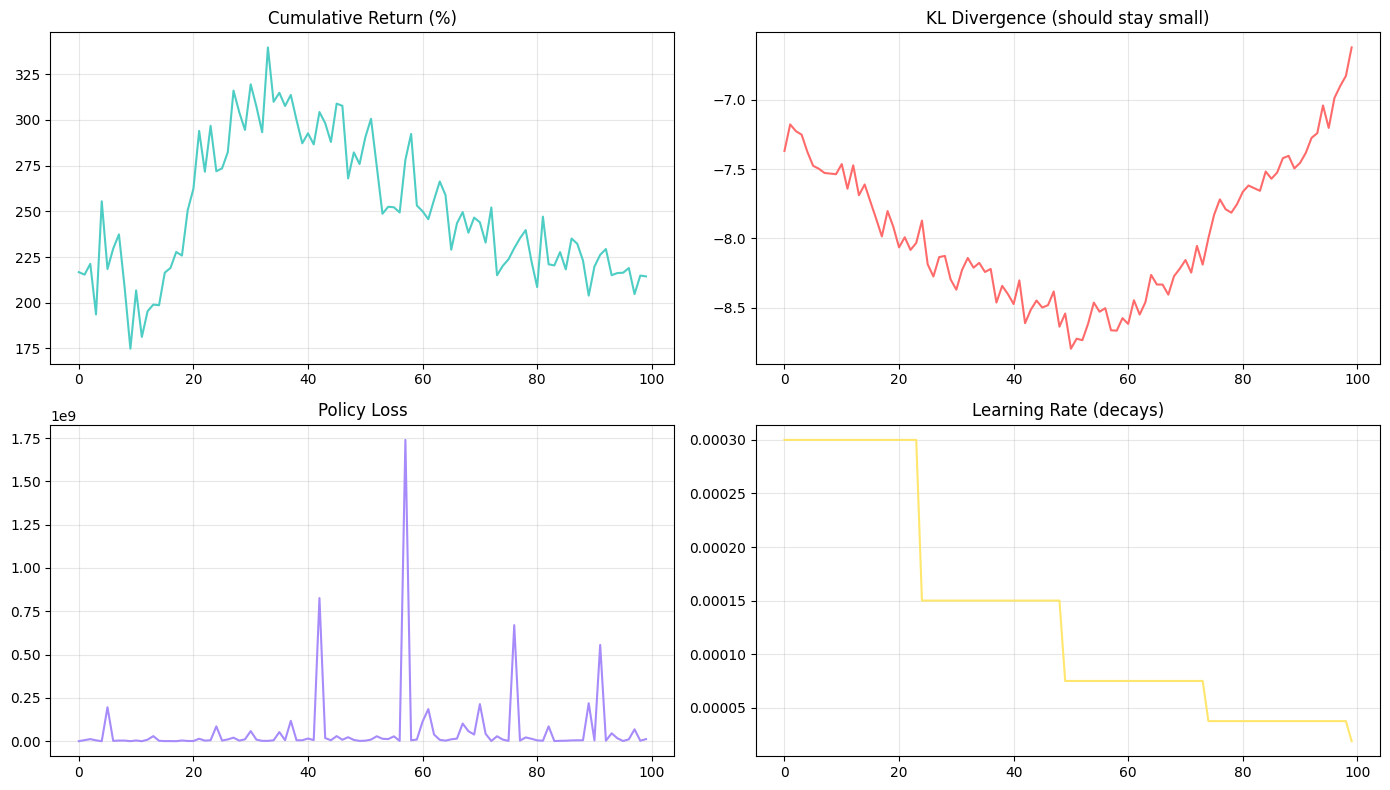

In [ ]:
# Cell 11: Training plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ep = [h['epoch'] for h in history]
axes[0,0].plot(ep, [h['cum_return_pct'] for h in history], color='#4ecdc4')
axes[0,0].set_title('Cumulative Return (%)'); axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(ep, [h['kl'] for h in history], color='#ff6b6b')
axes[0,1].set_title('KL Divergence (should stay small)'); axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(ep, [h['loss'] for h in history], color='#a78bfa')
axes[1,0].set_title('Policy Loss'); axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(ep, [h['lr'] for h in history], color='#ffe66d')
axes[1,1].set_title('Learning Rate (decays)'); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('logs/training_progress.png', dpi=150); plt.show()

In [ ]:
# Cell 12: Backtest on 2019-2023
trade_df = pd.read_csv('data/processed/trade_data_enhanced.csv')

# FIX #3: Use make_env with ref_wrapper to copy normalization stats
trade_env = make_env(trade_df, stock_dim, tech_indicators, warmup=False, ref_wrapper=env)

agent.load('checkpoints/best_model.pth')
obs, _ = trade_env.reset()
done = False
portfolio_values = [trade_env.initial_amount]
while not done:
    action = agent.predict(obs, deterministic=True)
    obs, reward, term, trunc, info = trade_env.step(action)
    done = term or trunc
    portfolio_values.append(info['total_asset'])

portfolio_values = np.array(portfolio_values).flatten()
print(f'Backtest: {len(portfolio_values)} days')
print(f'Final: ${portfolio_values[-1]:,.0f}')
print(f'Return: {(portfolio_values[-1]/portfolio_values[0]-1)*100:.2f}%')

Backtest: 1258 days
Final: $2,195,550
Return: 119.56%


In [ ]:
# Cell 13: Metrics
def cumulative_return(v): v=np.asarray(v).flatten(); return float((v[-1]/v[0])-1)
def max_drawdown(v): v=np.asarray(v).flatten(); p=np.maximum.accumulate(v); return float(((p-v)/p).max())
def rachev_ratio(r,a=0.05,b=0.05):
    r=np.sort(np.asarray(r).flatten()); n=len(r)
    cl=-r[:max(1,int(n*b))].mean(); cg=r[-max(1,int(n*a)):].mean()
    return float(cg/cl) if cl!=0 else float('inf')
def sharpe_ratio(r): r=np.asarray(r).flatten(); return float(np.sqrt(252)*r.mean()/r.std()) if r.std()>0 else 0.0
def outperformance_freq(pv,bv,w=63):
    pv,bv=np.asarray(pv).flatten(),np.asarray(bv).flatten()
    pr=pd.Series(pv).pct_change(w).dropna(); br=pd.Series(bv).pct_change(w).dropna()
    n=min(len(pr),len(br)); return float((pr.iloc[:n].values>br.iloc[:n].values).mean())

returns = np.diff(portfolio_values) / portfolio_values[:-1]

try:
    import yfinance as yf
    ndx = yf.download('^NDX', start='2019-01-01', end='2023-12-31', progress=False)
    benchmark = ndx['Close'].values.flatten()
    has_bench = True
except: has_bench = False; benchmark = None

print('='*55)
print('  BACKTEST RESULTS (2019-2023)')
print('='*55)
print(f'  Cumulative Return:      {cumulative_return(portfolio_values)*100:>10.2f}%')
print(f'  Max Drawdown:           {max_drawdown(portfolio_values)*100:>10.2f}%')
print(f'  Rachev Ratio:           {rachev_ratio(returns):>10.4f}')
print(f'  Sharpe Ratio:           {sharpe_ratio(returns):>10.4f}')
print(f'  Final Value:            ${portfolio_values[-1]:>12,.0f}')
if has_bench:
    br = cumulative_return(benchmark)
    print(f'  Benchmark Return:       {br*100:>10.2f}%')
    print(f'  Excess Return:          {(cumulative_return(portfolio_values)-br)*100:>10.2f}%')
    print(f'  Outperformance Freq:    {outperformance_freq(portfolio_values,benchmark)*100:>10.2f}%')
print('='*55)

  BACKTEST RESULTS (2019-2023)
  Cumulative Return:          119.56%
  Max Drawdown:                31.36%
  Rachev Ratio:               0.9288
  Sharpe Ratio:               0.8003
  Final Value:            $   2,195,550
  Benchmark Return:           164.52%
  Excess Return:              -44.97%
  Outperformance Freq:         38.08%


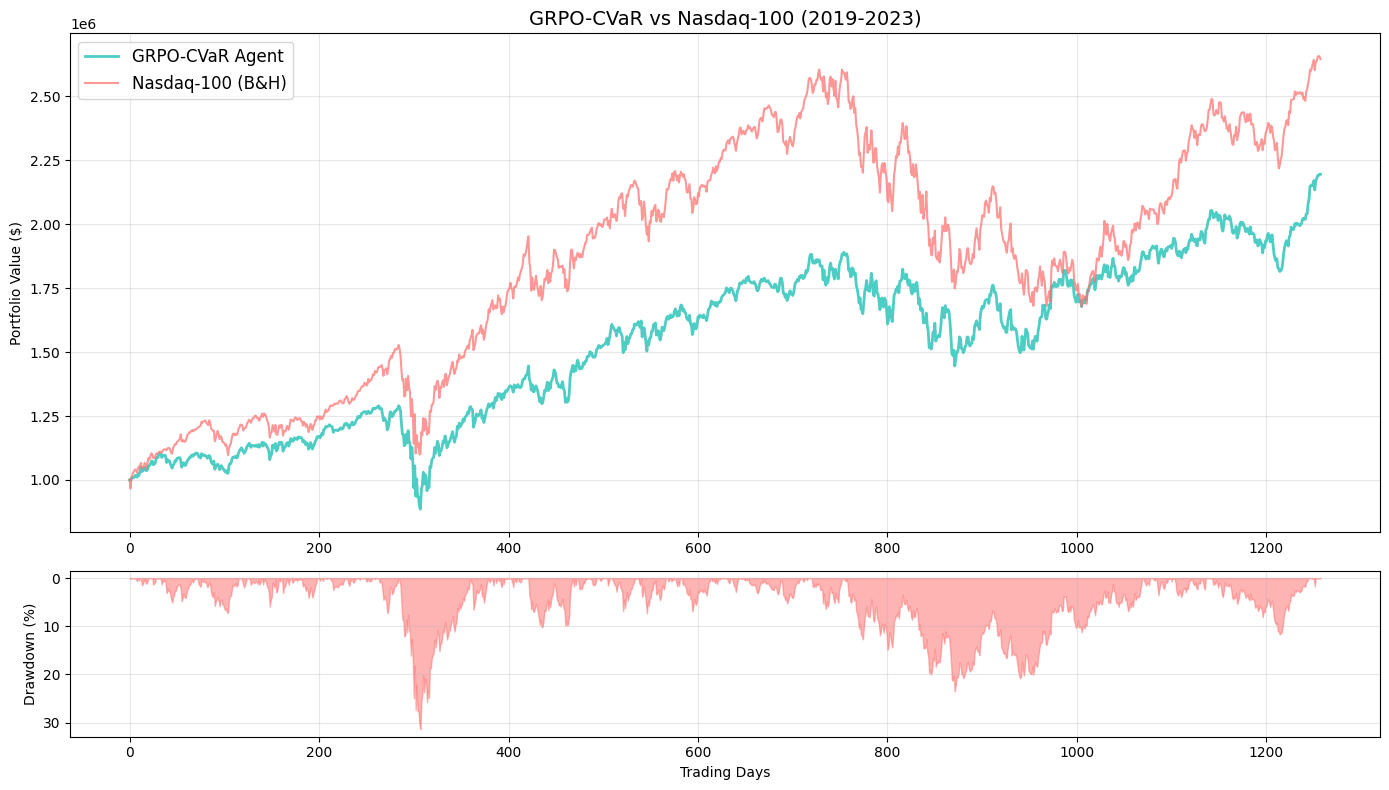

In [ ]:
# Cell 14: Backtest plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[3, 1])
days = range(len(portfolio_values))
axes[0].plot(days, portfolio_values, label='GRPO-CVaR Agent', linewidth=2, color='#4ecdc4')
if has_bench:
    nb = benchmark / benchmark[0] * portfolio_values[0]
    bd = np.linspace(0, len(portfolio_values)-1, len(nb))
    axes[0].plot(bd, nb, label='Nasdaq-100 (B&H)', linewidth=1.5, color='#ff6b6b', alpha=0.7)
axes[0].set_title('GRPO-CVaR vs Nasdaq-100 (2019-2023)', fontsize=14)
axes[0].set_ylabel('Portfolio Value ($)'); axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)
peak = np.maximum.accumulate(portfolio_values)
dd = (peak - portfolio_values) / peak * 100
axes[1].fill_between(days, dd, alpha=0.5, color='#ff6b6b')
axes[1].set_ylabel('Drawdown (%)'); axes[1].set_xlabel('Trading Days')
axes[1].grid(True, alpha=0.3); axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig('logs/backtest_results.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# Cell 15: FIX #4 — Ablation study WITH NormalizedEnvWrapper

ablation_configs = {
    'Full GRPO-CVaR':      dict(ss=True,  am=True,  rs=True,  cvar=True,  cg=True),
    'No CVaR':             dict(ss=True,  am=True,  rs=True,  cvar=False, cg=True),
    'No Reward Shaping':   dict(ss=True,  am=True,  rs=False, cvar=True,  cg=True),
    'No Confidence Gate':  dict(ss=True,  am=True,  rs=True,  cvar=True,  cg=False),
    'No Signals':          dict(ss=False, am=False, rs=False, cvar=True,  cg=False),
}

ablation_results = {}

for name, cfg in ablation_configs.items():
    print(f'\n{"="*50}\nAblation: {name}\n{"="*50}')

    # Build training env WITH normalization wrapper
    abl_train_env = make_env(
        train_df, stock_dim, tech_indicators,
        use_signal_state=cfg['ss'], use_action_modulation=cfg['am'],
        use_reward_shaping=cfg['rs'], confidence_gate=cfg['cg'], warmup=True
    )

    abl_agent = GRPOCVaR(
        env=abl_train_env, group_size=16, lr=3e-4,
        cvar_enabled=cfg['cvar'], hidden_sizes=[256,256], seed=42,
        max_kl=0.015, lr_decay_every=25, reward_clip=10.0
    )

    sp = f'checkpoints/abl_{name.replace(" ","_")}'
    abl_agent.train(total_epochs=30, save_path=sp)

    # Backtest WITH normalization (using training stats)
    abl_trade_env = make_env(
        trade_df, stock_dim, tech_indicators,
        use_signal_state=cfg['ss'], use_action_modulation=cfg['am'],
        use_reward_shaping=cfg['rs'], confidence_gate=cfg['cg'],
        warmup=False, ref_wrapper=abl_train_env
    )

    abl_agent.load(f'{sp}/best_model.pth')
    obs, _ = abl_trade_env.reset()
    done = False; vals = [1_000_000]
    while not done:
        a = abl_agent.predict(obs, deterministic=True)
        obs, _, term, trunc, info = abl_trade_env.step(a)
        done = term or trunc; vals.append(info['total_asset'])

    vals = np.array(vals).flatten()
    rets = np.diff(vals) / vals[:-1]
    ablation_results[name] = {
        'cum_return': cumulative_return(vals)*100,
        'max_dd': max_drawdown(vals)*100,
        'rachev': rachev_ratio(rets),
        'sharpe': sharpe_ratio(rets),
    }
    print(f'  Result: {ablation_results[name]["cum_return"]:.2f}% return')

print(f'\n{"="*70}')
print(f'{"Variant":<25} {"Cum Return":>12} {"Max DD":>10} {"Rachev":>10} {"Sharpe":>10}')
print(f'{"="*70}')
for n, r in ablation_results.items():
    print(f'{n:<25} {r["cum_return"]:>11.2f}% {r["max_dd"]:>9.2f}% {r["rachev"]:>10.4f} {r["sharpe"]:>10.4f}')
print(f'{"="*70}')
print('\nCopy these into Table 2 of the paper.')


Ablation: Full GRPO-CVaR
GRPO-CVaR: device=cpu, obs=1933, act=84, params=582,568
Ep   0 | Ret:   219.23% | Val: $3,192,322 | Loss: 749707.3125 | KL: -7.3733 | LR: 3.0e-04 | 31.9s
Ep   1 | Ret:   206.42% | Val: $3,064,152 | Loss: 905031.4375 | KL: -7.1756 | LR: 3.0e-04 | 32.8s
Ep   2 | Ret:   223.30% | Val: $3,233,011 | Loss: 15016302.0000 | KL: -7.2304 | LR: 3.0e-04 | 31.9s
Ep   3 | Ret:   190.19% | Val: $2,901,942 | Loss: 2775247.2500 | KL: -7.2682 | LR: 3.0e-04 | 32.9s
Ep   4 | Ret:   252.95% | Val: $3,529,458 | Loss: 261717.3594 | KL: -7.3941 | LR: 3.0e-04 | 31.7s
Ep   5 | Ret:   235.66% | Val: $3,356,586 | Loss: 290012.2188 | KL: -7.4704 | LR: 3.0e-04 | 33.0s
Ep   6 | Ret:   246.83% | Val: $3,468,260 | Loss: 557550.8750 | KL: -7.4902 | LR: 3.0e-04 | 31.9s
Ep   7 | Ret:   261.13% | Val: $3,611,298 | Loss: 147629184.0000 | KL: -7.4999 | LR: 3.0e-04 | 32.9s
Ep   8 | Ret:   231.43% | Val: $3,314,292 | Loss: 4078124.0000 | KL: -7.5494 | LR: 3.0e-04 | 32.0s
Ep   9 | Ret:   181.63% | Val

In [ ]:
# Cell 16: Save everything
pd.DataFrame({'day': range(len(portfolio_values)), 'value': portfolio_values}).to_csv('logs/portfolio_values.csv', index=False)
pd.DataFrame(history).to_csv('logs/training_history.csv', index=False)
pd.DataFrame(ablation_results).T.to_csv('logs/ablation_results.csv')

import shutil
shutil.make_archive('/content/finrl_results', 'zip', '.', 'logs')
shutil.make_archive('/content/finrl_checkpoints', 'zip', '.', 'checkpoints')

print('Download from Colab Files panel:')
print('  /content/finrl_results.zip')
print('  /content/finrl_checkpoints.zip')


Download from Colab Files panel:
  /content/finrl_results.zip
  /content/finrl_checkpoints.zip

Update your paper with the new numbers.
